In [42]:
"""
movement_detection.ipynb
========================
Investigates the ratiometric degeneracy inherent to mass-photometry movement
detection.

A particle of mass M moving distance d produces an identical ratiometric
footprint to a particle of mass 2M moving d/2.  This notebook:

  1. Demonstrates the degeneracy analytically on a noise-free background.
  2. Simulates both scenarios on experimental buffer-movie backgrounds.
  3. Explores the error landscape as a function of probe distance.
  4. Visualises the movements as 3-D surfaces.
"""
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

from alex_area import utils, plotting
from alex_area.movie_generator.buffer_movies import BufferMovie, load_buffer_movies
from alex_area.movie_generator.sim_movie import BufferMovieSim, CachedPSF
from alex_area.pairmatching_benchmark.mass_pos_err_bench import rand_l_thum_stack
from tandemmp.utils.conversions import conversion_funcs


## Configuration

In [43]:
# --- File paths ---
PSF_PATH = (
    r"C:\Users\chem-bras5436\Documents\MP_DATA\citrate_synthase\TwoMP"
    r"\buffer_movies\unbinned\011_20241115_s_elo_wt_his_tag_7500x_expPSF.pickle"
)

# --- Geometry ---
L_THUM = 21        # Thumbnail side length (pixels)
N_SAMPLE = 21      # Grid sample density for noise-free PSF evaluation
STACK_LENGTH = 11  # Frames per simulated buffer-movie stack

# --- Calibration ---
NM_PER_PIXEL = 72.6  # Spatial calibration (nm px⁻¹)

# Convenience: plot extent in pixel-unit coordinates
EXTENT = [-L_THUM / 2, L_THUM / 2, -L_THUM / 2, L_THUM / 2]

# --- Buffer movie ---
B_MOVS: list[BufferMovie] = load_buffer_movies()
B_MOV = B_MOVS[0]

## 1. Load Experimental PSF

In [44]:
_raw_psf = utils.load_from_pickle(PSF_PATH)


def expPSF(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Evaluate the experimental PSF at arbitrary (x, y) coordinates.

    Thin wrapper around the raw RectBivariateSpline interpolator that fixes
    ``grid=False`` so callers can pass flat coordinate arrays directly.

    Parameters
    ----------
    x, y:
        Coordinate arrays in pixel units, as returned by
        ``CachedPSF._gen_offset_mgrid``.

    Returns
    -------
    np.ndarray
        PSF amplitude at each coordinate pair.
    """
    return _raw_psf(x, y, grid=False)


## 2. Helper Functions

In [45]:
def make_movement_thumbnail(
    mass: float,
    distance_nm: float,
    psf_fn,
    *,
    x_off: float = 0.0,
    y_off: float = 0.0,
    l_thum: int = L_THUM,
    n_sample: int = N_SAMPLE,
) -> np.ndarray:
    """Compute the ideal (noise-free) ratiometric thumbnail for a moving particle.

    Models the movement as a dipole: the particle departs its start position
    (positive lobe) and arrives at its end position (negative lobe), consistent
    with the sign convention used by ``BufferMovieSim``.

    Parameters
    ----------
    mass:
        Particle mass in kDa.
    distance_nm:
        Distance moved in nm (along x).
    psf_fn:
        Callable ``(x, y) -> ndarray`` returning PSF amplitude.
    x_off, y_off:
        Centre-of-mass offset from the thumbnail centre in pixels.
    l_thum:
        Thumbnail side length in pixels.
    n_sample:
        Number of sample points per axis for PSF evaluation.

    Returns
    -------
    np.ndarray
        2-D ratiometric footprint, shape ``(n_sample, n_sample)``.
    """
    contrast  = conversion_funcs["mass_to_c"](mass)
    half_dist = (distance_nm / NM_PER_PIXEL) / 2

    xx_dep, yy_dep = CachedPSF._gen_offset_mgrid(
        x_off=x_off - half_dist, y_off=y_off,
        min=-l_thum / 2, max=l_thum / 2, num=n_sample,
    )
    xx_arr, yy_arr = CachedPSF._gen_offset_mgrid(
        x_off=x_off + half_dist, y_off=y_off,
        min=-l_thum / 2, max=l_thum / 2, num=n_sample,
    )

    departure =  contrast * psf_fn(xx_dep, yy_dep)  # particle leaves → positive contrast
    arrival   = -contrast * psf_fn(xx_arr, yy_arr)  # particle arrives → negative contrast
    return departure + arrival


def simulate_ratiometric_frame(
    mass: float,
    distance_nm: float,
    background_stack: np.ndarray,
    simulator: BufferMovieSim,
    *,
    x_off: float = 0.0,
    y_off: float = 0.0,
) -> np.ndarray:
    """Simulate a ratiometric frame for a single moving particle on a buffer background.

    Embeds a two-event movement (departure + arrival) into the temporal midpoint
    of *background_stack* and returns ``post / pre - 1``, where *pre* and *post*
    are the per-pixel temporal means before and after the event frame.

    Parameters
    ----------
    mass:
        Particle mass in kDa.
    distance_nm:
        Distance moved in nm (along x).
    background_stack:
        Raw buffer-movie patch, shape ``(STACK_LENGTH, L_THUM, L_THUM)``.
        This array is not modified in place.
    simulator:
        Initialised ``BufferMovieSim`` instance.
    x_off, y_off:
        Particle offset from the thumbnail centre in pixels.

    Returns
    -------
    np.ndarray
        Ratiometric frame ``post / pre - 1``, shape ``(L_THUM, L_THUM)``.
    """
    n_frames  = background_stack.shape[0]
    l_px      = background_stack.shape[1]
    centre    = l_px // 2           # array-index centre (e.g. 10 for L_THUM=21)
    midframe  = n_frames // 2       # event frame index  (e.g.  5 for STACK_LENGTH=11)
    contrast  = conversion_funcs["mass_to_c"](mass)
    half_dist = (distance_nm / NM_PER_PIXEL) / 2

    events = [  # [x_px, y_px, frame_idx, contrast_value]
        [centre + x_off - half_dist, centre + y_off, midframe, -contrast],
        [centre + x_off + half_dist, centre + y_off, midframe,  contrast],
    ]

    sim  = simulator.work(movie=background_stack.copy(), events=events).astype(np.int32)
    pre  = sim[:midframe].mean(axis=0)
    post = sim[midframe:].mean(axis=0)
    return post / pre - 1


def configure_pixel_axes(ax: plt.Axes, major: int = 5, minor: int = 1) -> None:
    """Set major and minor tick intervals (in pixels) on both axes of *ax*.

    Parameters
    ----------
    ax:
        Axes to configure.
    major, minor:
        Tick spacing in pixels.
    """
    ax.xaxis.set_major_locator(MultipleLocator(major))
    ax.yaxis.set_major_locator(MultipleLocator(major))
    ax.xaxis.set_minor_locator(MultipleLocator(minor))
    ax.yaxis.set_minor_locator(MultipleLocator(minor))


## 3. Ratiometric Degeneracy — Noise-Free Background

A particle of mass M moving distance d produces an identical ratiometric footprint
to a particle of mass 2M moving d/2.  The difference image quantifies how
indistinguishable the two scenarios are when background noise is absent.

4.163752627662054 4.1083089366744705


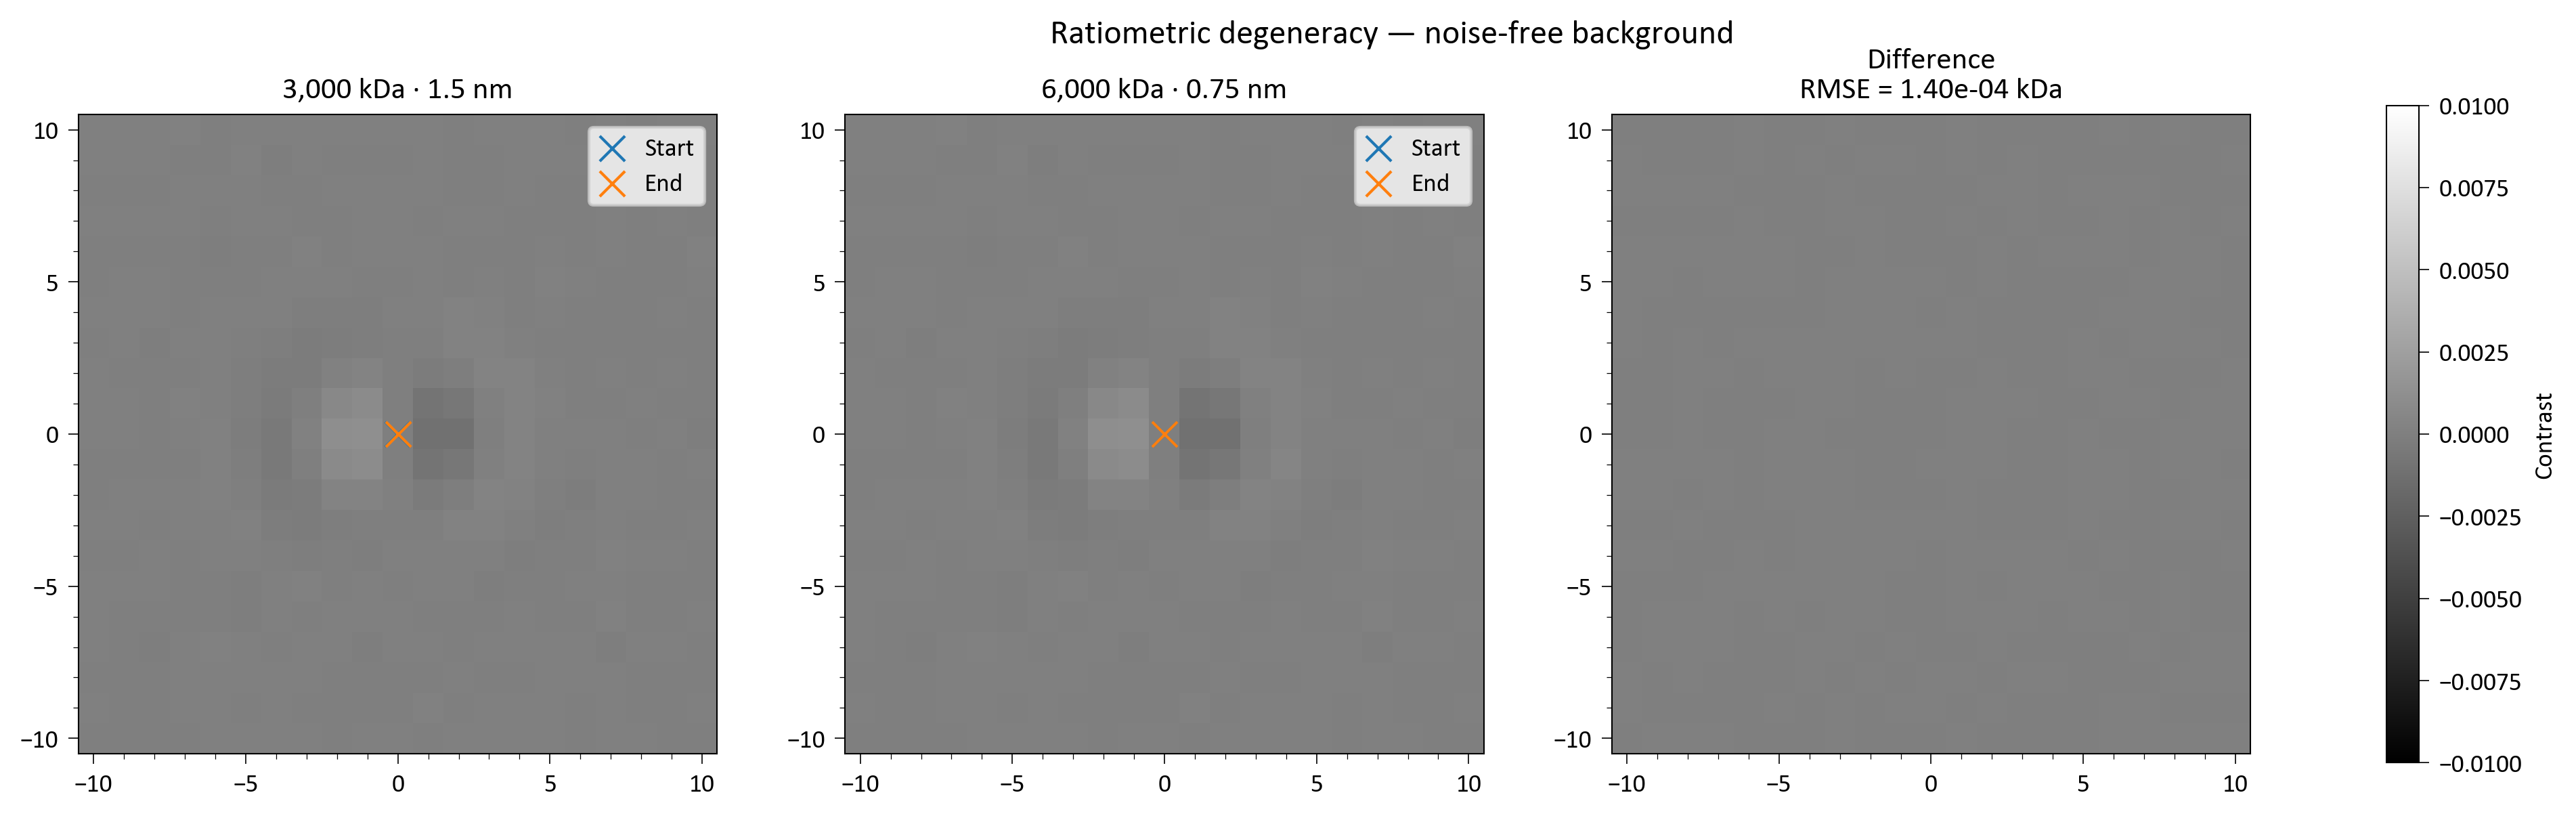

In [46]:
CASES = [
    {"mass": 3_000, "distance_nm": 1.5},
    {"mass": 6_000, "distance_nm": 0.75},
]

thumbnails = [make_movement_thumbnail(c["mass"], c["distance_nm"], expPSF) for c in CASES]
difference = thumbnails[0] - thumbnails[1]

fig, axs = plt.subplots(
    1, 3, dpi=300,
    figsize=(3 * plotting.DEFAULT_FIG_SIZE[0], 1.1 * plotting.DEFAULT_FIG_SIZE[1]),
)

vmin, vmax = -0.01, 0.01
for ax, img, case in zip(axs[:2], thumbnails, CASES):
    half_dist_px = (case["distance_nm"] / NM_PER_PIXEL) / 2
    ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax, extent=EXTENT)
    ax.scatter(-half_dist_px, 0, s=80, linewidth=1, marker="x", label="Start")
    ax.scatter(+half_dist_px, 0, s=80, linewidth=1, marker="x", label="End")
    ax.legend(handlelength=1.0, loc="upper right")
    ax.set_title(f"{case['mass']:,} kDa · {case['distance_nm']} nm")
    configure_pixel_axes(ax)

axs[2].imshow(difference, cmap="gray", vmin=vmin, vmax=vmax, extent=EXTENT)
axs[2].set_title(f"Difference\nRMSE = {conversion_funcs["mass_to_c"](np.sqrt(np.mean(difference**2))):.2e} kDa")
configure_pixel_axes(axs[2])

plt.colorbar(axs[2].images[0], ax=axs, label="Contrast")


fig.suptitle(
    "Ratiometric degeneracy — noise-free background",
    fontsize=plotting.DEFAULT_TITLE_SIZE,
)
print(conversion_funcs["c_to_mass"](np.sort(difference.flatten())[0]), conversion_funcs["c_to_mass"](np.sort(difference.flatten())[-1]))

plt.show()


## 4. Simulating on a Flat Movie

Generate a spatially-uniform background (every pixel = 32 767) and apply
Poisson noise with the same ×360 gain scaling used in §5.  This isolates
the effect of photon shot-noise without any spatial structure in the background.

In [47]:
FLAT_VALUE = 32_767   # uniform background level (2^15 - 1 ADU)

rng = np.random.default_rng(seed=42)

# Calibration and simulator — same for all simulated-background sections
calibration = B_MOV.calibration
conversion_funcs["c_to_mass"] = lambda c: (c - calibration["intercept"]) / calibration["c2kDa"]
conversion_funcs["mass_to_c"] = lambda m: m * calibration["c2kDa"] + calibration["intercept"]

psf_model = CachedPSF(psf_model=expPSF, l_thum=L_THUM, precision=0.01)
simulator  = BufferMovieSim(psf_model=psf_model)

# Generate a Poisson-noise flat stack directly at thumbnail size.
# Every spatial patch is statistically equivalent, so rand_l_thum_stack is unnecessary.
flat_lam   = FLAT_VALUE * 360                # photon-space lambda (×360 gain factor)
flat_stack = (
    rng.poisson(flat_lam, size=(STACK_LENGTH, L_THUM, L_THUM)) / 360.0
).astype(np.uint16)

### 4.1 Ratiometric Movements on a Flat Background

Both degenerate scenarios are simulated on the same flat stack so that
shot-noise contributes identically to both frames.

Adding events: 100%|██████████| 2/2 [00:00<00:00, 1999.19events/s]


38.50758752919126 -29.174403404811866


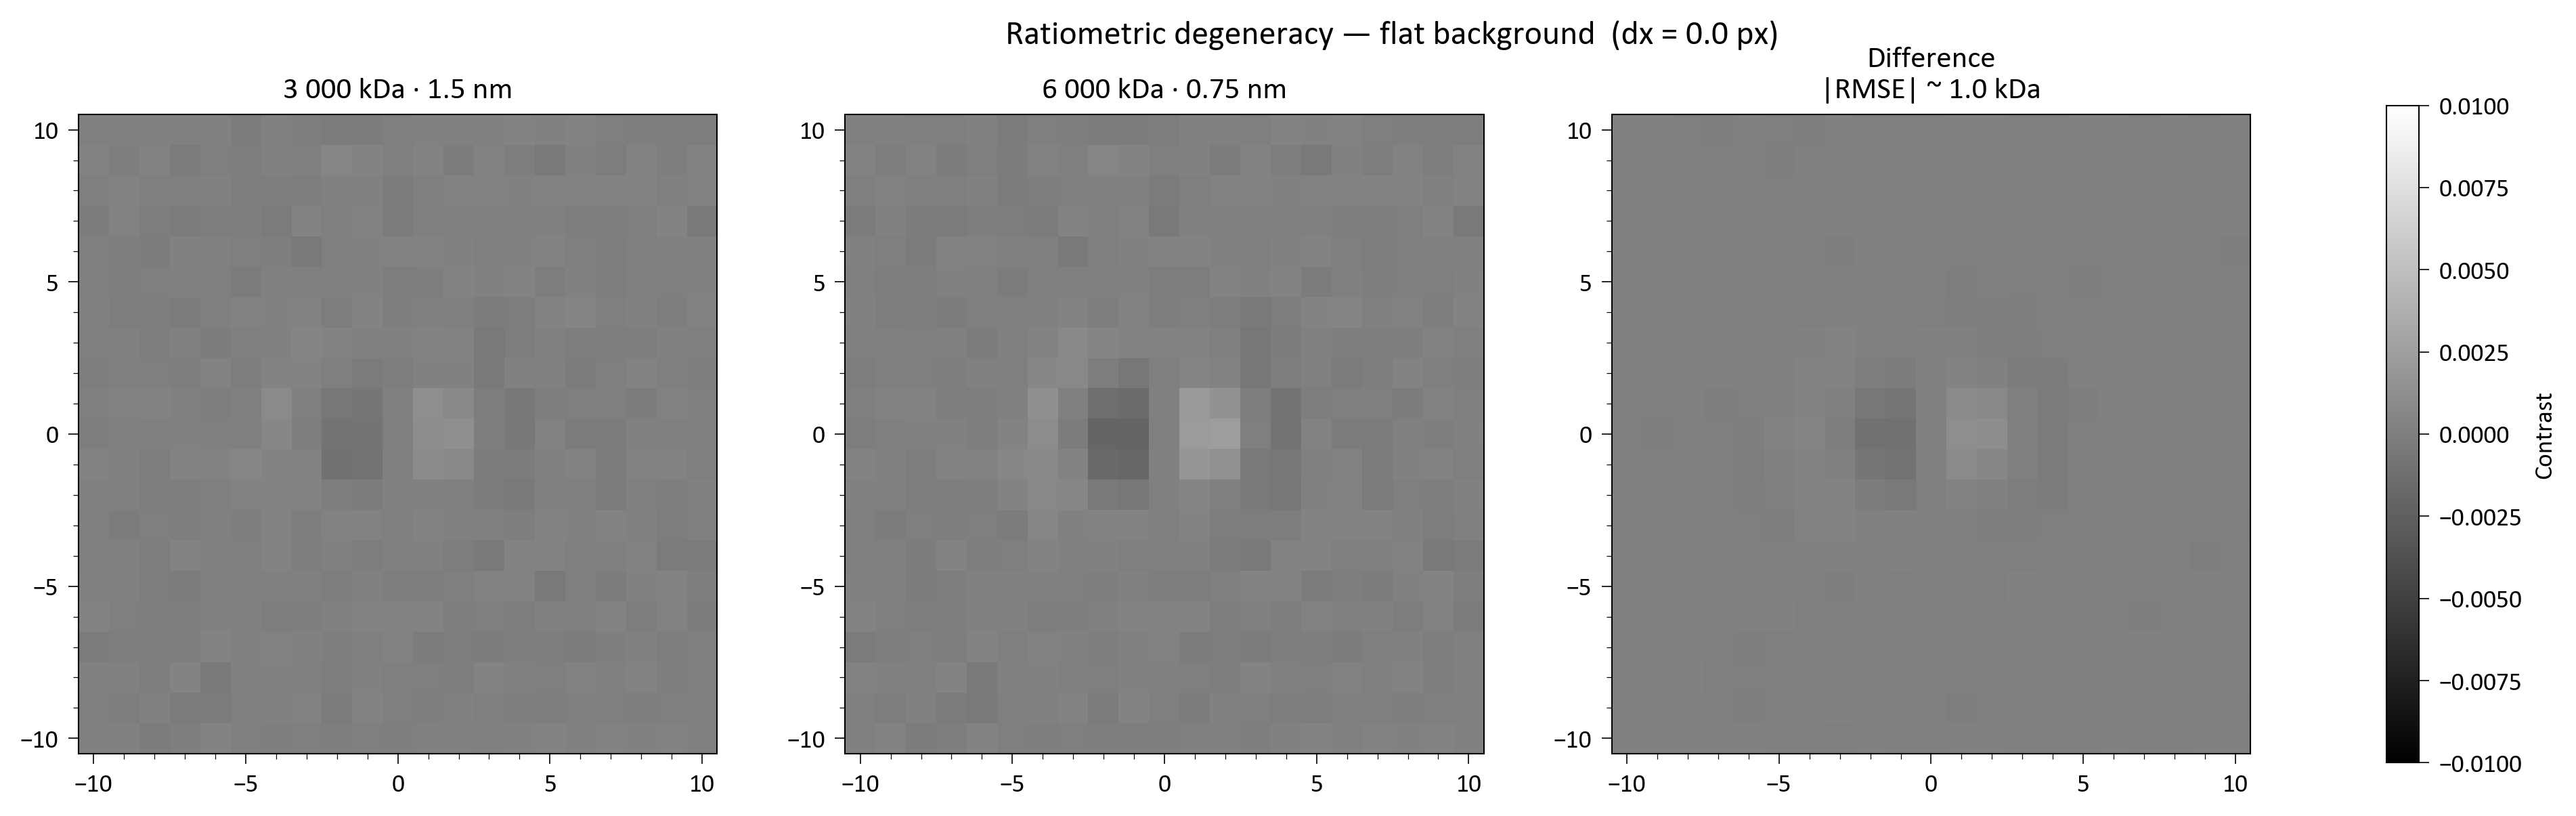

In [48]:
FLAT_DISTANCE_NM = 1.5
X_OFFSET_PX = 0.0   # sub-pixel lateral offset from thumbnail centre

r_3000_flat = simulate_ratiometric_frame(3_000, FLAT_DISTANCE_NM,      flat_stack, simulator, x_off=X_OFFSET_PX)
r_6000_flat = simulate_ratiometric_frame(6_000, FLAT_DISTANCE_NM / 2,  flat_stack, simulator, x_off=X_OFFSET_PX)

diff_flat     = r_6000_flat - r_3000_flat
diff_kda_flat = np.abs(conversion_funcs["c_to_mass"](np.sqrt(np.mean(diff_flat**2))))

fig, axs = plt.subplots(
    1, 3, dpi=300,
    figsize=(3 * plotting.DEFAULT_FIG_SIZE[0], 1.1 * plotting.DEFAULT_FIG_SIZE[1]),
)

vmin, vmax = -0.01, 0.01
axs[0].imshow(r_3000_flat, cmap="gray", extent=EXTENT, vmin=vmin, vmax=vmax)
axs[0].set_title(f"3 000 kDa · {FLAT_DISTANCE_NM} nm")

axs[1].imshow(r_6000_flat, cmap="gray", extent=EXTENT, vmin=vmin, vmax=vmax)
axs[1].set_title(f"6 000 kDa · {FLAT_DISTANCE_NM / 2} nm")

axs[2].imshow(diff_flat, cmap="gray", extent=EXTENT, vmin=vmin, vmax=vmax)
axs[2].set_title(f"Difference\n|RMSE| ~ {diff_kda_flat:.1f} kDa")

for ax in axs:
    configure_pixel_axes(ax)

plt.colorbar(axs[2].images[0], ax=axs, label="Contrast")
fig.suptitle(
    f"Ratiometric degeneracy — flat background  (dx = {X_OFFSET_PX} px)",
    fontsize=plotting.DEFAULT_TITLE_SIZE,
)
print(conversion_funcs["c_to_mass"](np.sort(diff_flat.flatten())[0]), conversion_funcs["c_to_mass"](np.sort(diff_flat.flatten())[-1]))

plt.show()

## 5. Simulation Setup — Idealised Poisson-noise-only Background

Generate an idealised movie with Poisson noise only, using the first frame
of the buffer movie as the spatially-varying lambda map.

In [49]:
rng = np.random.default_rng(seed=8)   # fresh seed for reproducible idealised noise
b_mov = B_MOV

length, height, width = b_mov.shape
lam_scaled = np.clip(b_mov[0].astype(int), 0, None) * 360  # non-negative photon-space lambda

# Generate idealised Poisson-noise-only movie (spatial structure from buffer frame 0)
ideal_noisy_mov = (
    rng.poisson(lam_scaled, size=(length, height, width)) / 360.0
).astype(np.uint16)

# Calibration and simulator (same parameters as §4 and §6)
calibration = b_mov.calibration
conversion_funcs["c_to_mass"] = lambda c: (c - calibration["intercept"]) / calibration["c2kDa"]
conversion_funcs["mass_to_c"] = lambda m: m * calibration["c2kDa"] + calibration["intercept"]

psf_model = CachedPSF(psf_model=expPSF, l_thum=L_THUM, precision=0.01)
simulator  = BufferMovieSim(psf_model=psf_model)

### 5.1 Ratiometric Movements on an Idealised Background

Both degenerate scenarios are simulated on the same randomly-sampled patch of
``ideal_noisy_mov`` so that Poisson noise contributes identically to both frames.

Adding events: 100%|██████████| 2/2 [00:00<00:00, 2003.97events/s]


37.078610919848785 -29.287801490936314


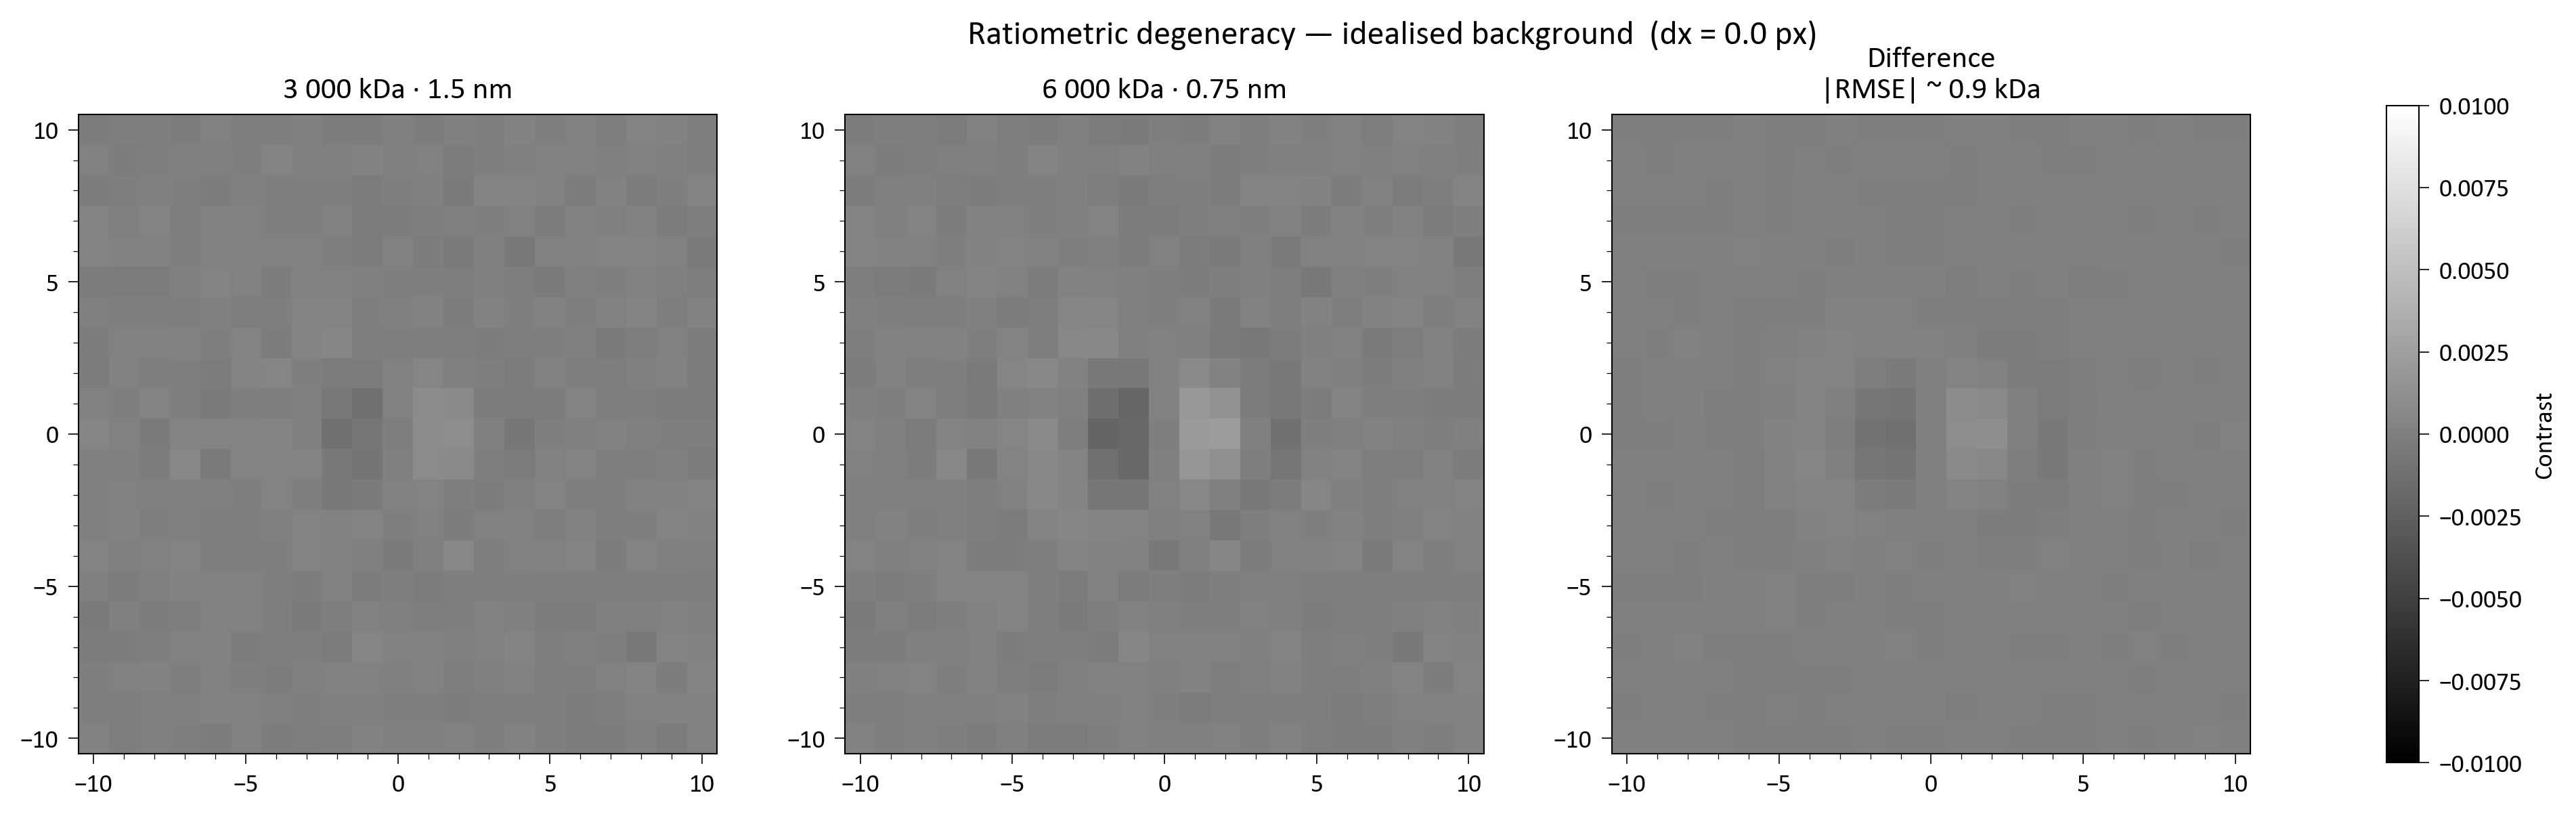

In [50]:
rand_stack = rand_l_thum_stack(arr=ideal_noisy_mov, l_thum=L_THUM, length=STACK_LENGTH)

IDEAL_DISTANCE_NM = 1.5
X_OFFSET_PX = 0.0   # sub-pixel lateral offset from thumbnail centre

r_3000_ideal = simulate_ratiometric_frame(3_000, IDEAL_DISTANCE_NM,      rand_stack, simulator, x_off=X_OFFSET_PX)
r_6000_ideal = simulate_ratiometric_frame(6_000, IDEAL_DISTANCE_NM / 2,  rand_stack, simulator, x_off=X_OFFSET_PX)

diff_ideal     = r_6000_ideal - r_3000_ideal
diff_kda_ideal = np.abs(conversion_funcs["c_to_mass"](np.sqrt(np.mean(diff_ideal**2))))

fig, axs = plt.subplots(
    1, 3, dpi=300,
    figsize=(3 * plotting.DEFAULT_FIG_SIZE[0], 1.1 * plotting.DEFAULT_FIG_SIZE[1]),
)

vmin, vmax = -0.01, 0.01
axs[0].imshow(r_3000_ideal, cmap="gray", extent=EXTENT, vmin=vmin, vmax=vmax)
axs[0].set_title(f"3 000 kDa · {IDEAL_DISTANCE_NM} nm")

axs[1].imshow(r_6000_ideal, cmap="gray", extent=EXTENT, vmin=vmin, vmax=vmax)
axs[1].set_title(f"6 000 kDa · {IDEAL_DISTANCE_NM / 2} nm")

axs[2].imshow(diff_ideal, cmap="gray", extent=EXTENT, vmin=vmin, vmax=vmax)
axs[2].set_title(f"Difference\n|RMSE| ~ {diff_kda_ideal:.1f} kDa")

for ax in axs:
    configure_pixel_axes(ax)

plt.colorbar(axs[2].images[0], ax=axs, label="Contrast")
fig.suptitle(
    f"Ratiometric degeneracy — idealised background  (dx = {X_OFFSET_PX} px)",
    fontsize=plotting.DEFAULT_TITLE_SIZE,
)
print(conversion_funcs["c_to_mass"](np.sort(diff_ideal.flatten())[0]), conversion_funcs["c_to_mass"](np.sort(diff_ideal.flatten())[-1]))

plt.show()

## 6. Simulation Setup — Buffer Movie Background

Load a real buffer movie and override the contrast-to-mass conversion with the
calibration embedded in that movie.  All subsequent simulations use the same
``simulator`` instance.

In [51]:
b_mov = B_MOV

# Override with the buffer-movie calibration so mass <-> contrast is self-consistent
calibration = b_mov.calibration
conversion_funcs["c_to_mass"] = lambda c: (c - calibration["intercept"]) / calibration["c2kDa"]
conversion_funcs["mass_to_c"] = lambda m: m * calibration["c2kDa"] + calibration["intercept"]

psf_model = CachedPSF(psf_model=expPSF, l_thum=L_THUM, precision=0.01)
simulator  = BufferMovieSim(psf_model=psf_model)


## 7. Ratiometric Movements on a Buffer Background

Both degenerate scenarios are simulated on the **same** randomly-sampled buffer
region so that photon and read-out noise contribute identically to both frames.

Adding events: 100%|██████████| 2/2 [00:00<00:00, 1995.39events/s]


37.74907743851784 -28.15789575410439


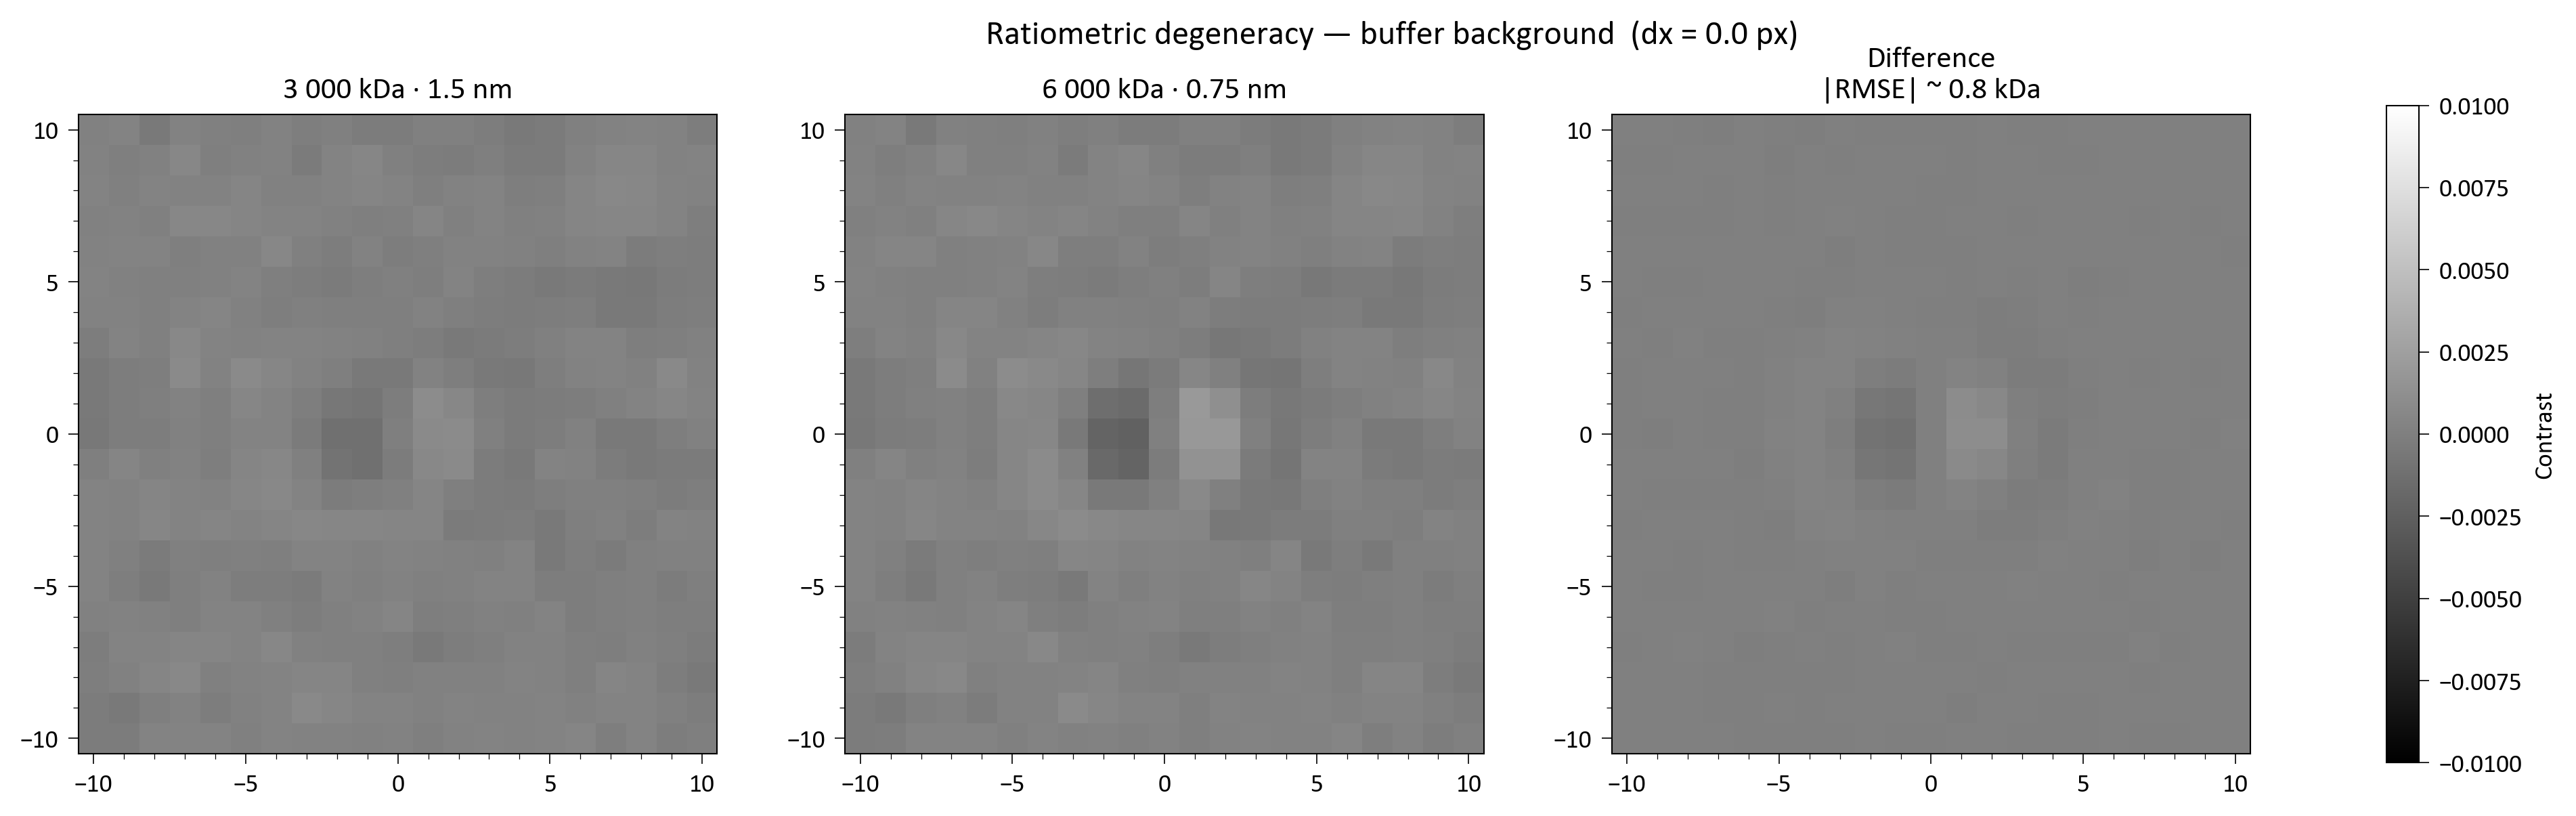

In [52]:
rand_stack = rand_l_thum_stack(arr=b_mov, l_thum=L_THUM, length=STACK_LENGTH)

BUFFER_DISTANCE_NM = 1.5
X_OFFSET_PX = 0.0   # sub-pixel lateral offset from thumbnail centre

r_3000 = simulate_ratiometric_frame(3_000, BUFFER_DISTANCE_NM,      rand_stack, simulator, x_off=X_OFFSET_PX)
r_6000 = simulate_ratiometric_frame(6_000, BUFFER_DISTANCE_NM / 2,  rand_stack, simulator, x_off=X_OFFSET_PX)

diff     = r_6000 - r_3000
diff_kda = np.abs(conversion_funcs["c_to_mass"](np.sqrt(np.mean(diff**2))))

fig, axs = plt.subplots(
    1, 3, dpi=300,
    figsize=(3 * plotting.DEFAULT_FIG_SIZE[0], 1.1 * plotting.DEFAULT_FIG_SIZE[1]),
)

vmin, vmax = -0.01, 0.01
axs[0].imshow(r_3000, cmap="gray", extent=EXTENT, vmin=vmin, vmax=vmax)
axs[0].set_title(f"3 000 kDa · {BUFFER_DISTANCE_NM} nm")

axs[1].imshow(r_6000, cmap="gray", extent=EXTENT, vmin=vmin, vmax=vmax)
axs[1].set_title(f"6 000 kDa · {BUFFER_DISTANCE_NM / 2} nm")

axs[2].imshow(diff, cmap="gray", extent=EXTENT, vmin=vmin, vmax=vmax)
axs[2].set_title(f"Difference\n|RMSE| ~ {diff_kda:.1f} kDa")

for ax in axs:
    configure_pixel_axes(ax)

plt.colorbar(axs[2].images[0], ax=axs, label="Contrast")
fig.suptitle(
    f"Ratiometric degeneracy — buffer background  (dx = {X_OFFSET_PX} px)",
    fontsize=plotting.DEFAULT_TITLE_SIZE,
)
print(conversion_funcs["c_to_mass"](np.sort(diff.flatten())[0]), conversion_funcs["c_to_mass"](np.sort(diff.flatten())[-1]))
plt.show()

## 8. Error Landscape — Distance Sensitivity

Fix the target at 3 000 kDa · 5 nm and sweep probe distances at a nearby mass
(3 500 kDa) to characterise how the pixel-space RMSE changes with the hypothesised
distance.  The minimum of this curve identifies the best-fit distance for that
probe mass.

Adding events: 100%|██████████| 2/2 [00:00<?, ?events/s]


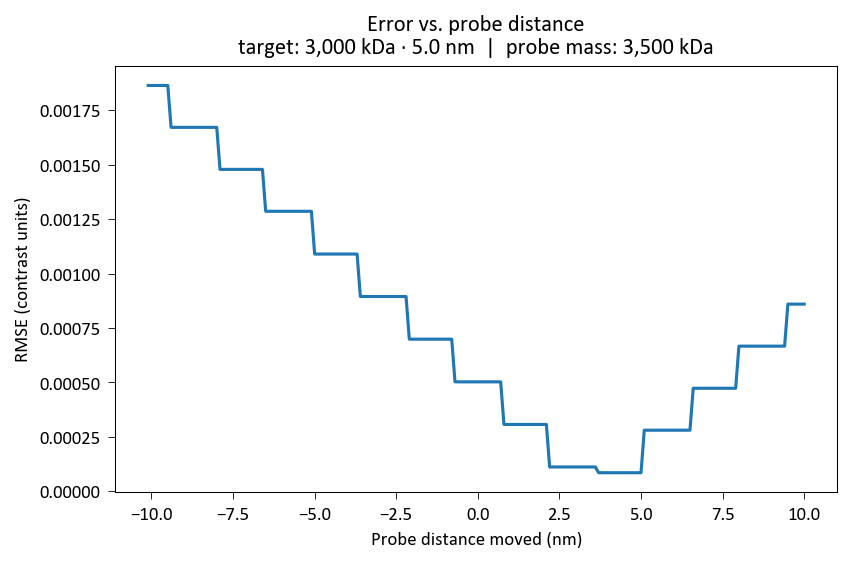

In [31]:
rand_stack = rand_l_thum_stack(arr=b_mov, l_thum=L_THUM, length=STACK_LENGTH)

TARGET_MASS_KDA = 3_000
TARGET_DIST_NM  = 5.0
PROBE_MASS_KDA  = 3_500

r_target = simulate_ratiometric_frame(TARGET_MASS_KDA, TARGET_DIST_NM, rand_stack, simulator)

probe_distances_nm = np.arange(-10.1, 10.1, 0.1)
errors = np.array([
    np.sqrt(np.mean(
        (simulate_ratiometric_frame(PROBE_MASS_KDA, d, rand_stack, simulator) - r_target) ** 2
    ))
    for d in probe_distances_nm
])

fig, ax = plt.subplots(dpi=150, figsize=plotting.DEFAULT_FIG_SIZE)
ax.plot(probe_distances_nm, errors)
ax.set_xlabel("Probe distance moved (nm)")
ax.set_ylabel("RMSE (contrast units)")
ax.set_title(
    f"Error vs. probe distance\n"
    f"target: {TARGET_MASS_KDA:,} kDa · {TARGET_DIST_NM} nm  |  "
    f"probe mass: {PROBE_MASS_KDA:,} kDa"
)
plt.tight_layout()
plt.show()


## 9. 3-D Surface Visualisation

Surface plots of the two degenerate ratiometric frames (§5) and their difference,
viewed along the y-axis to highlight the dipole structure.

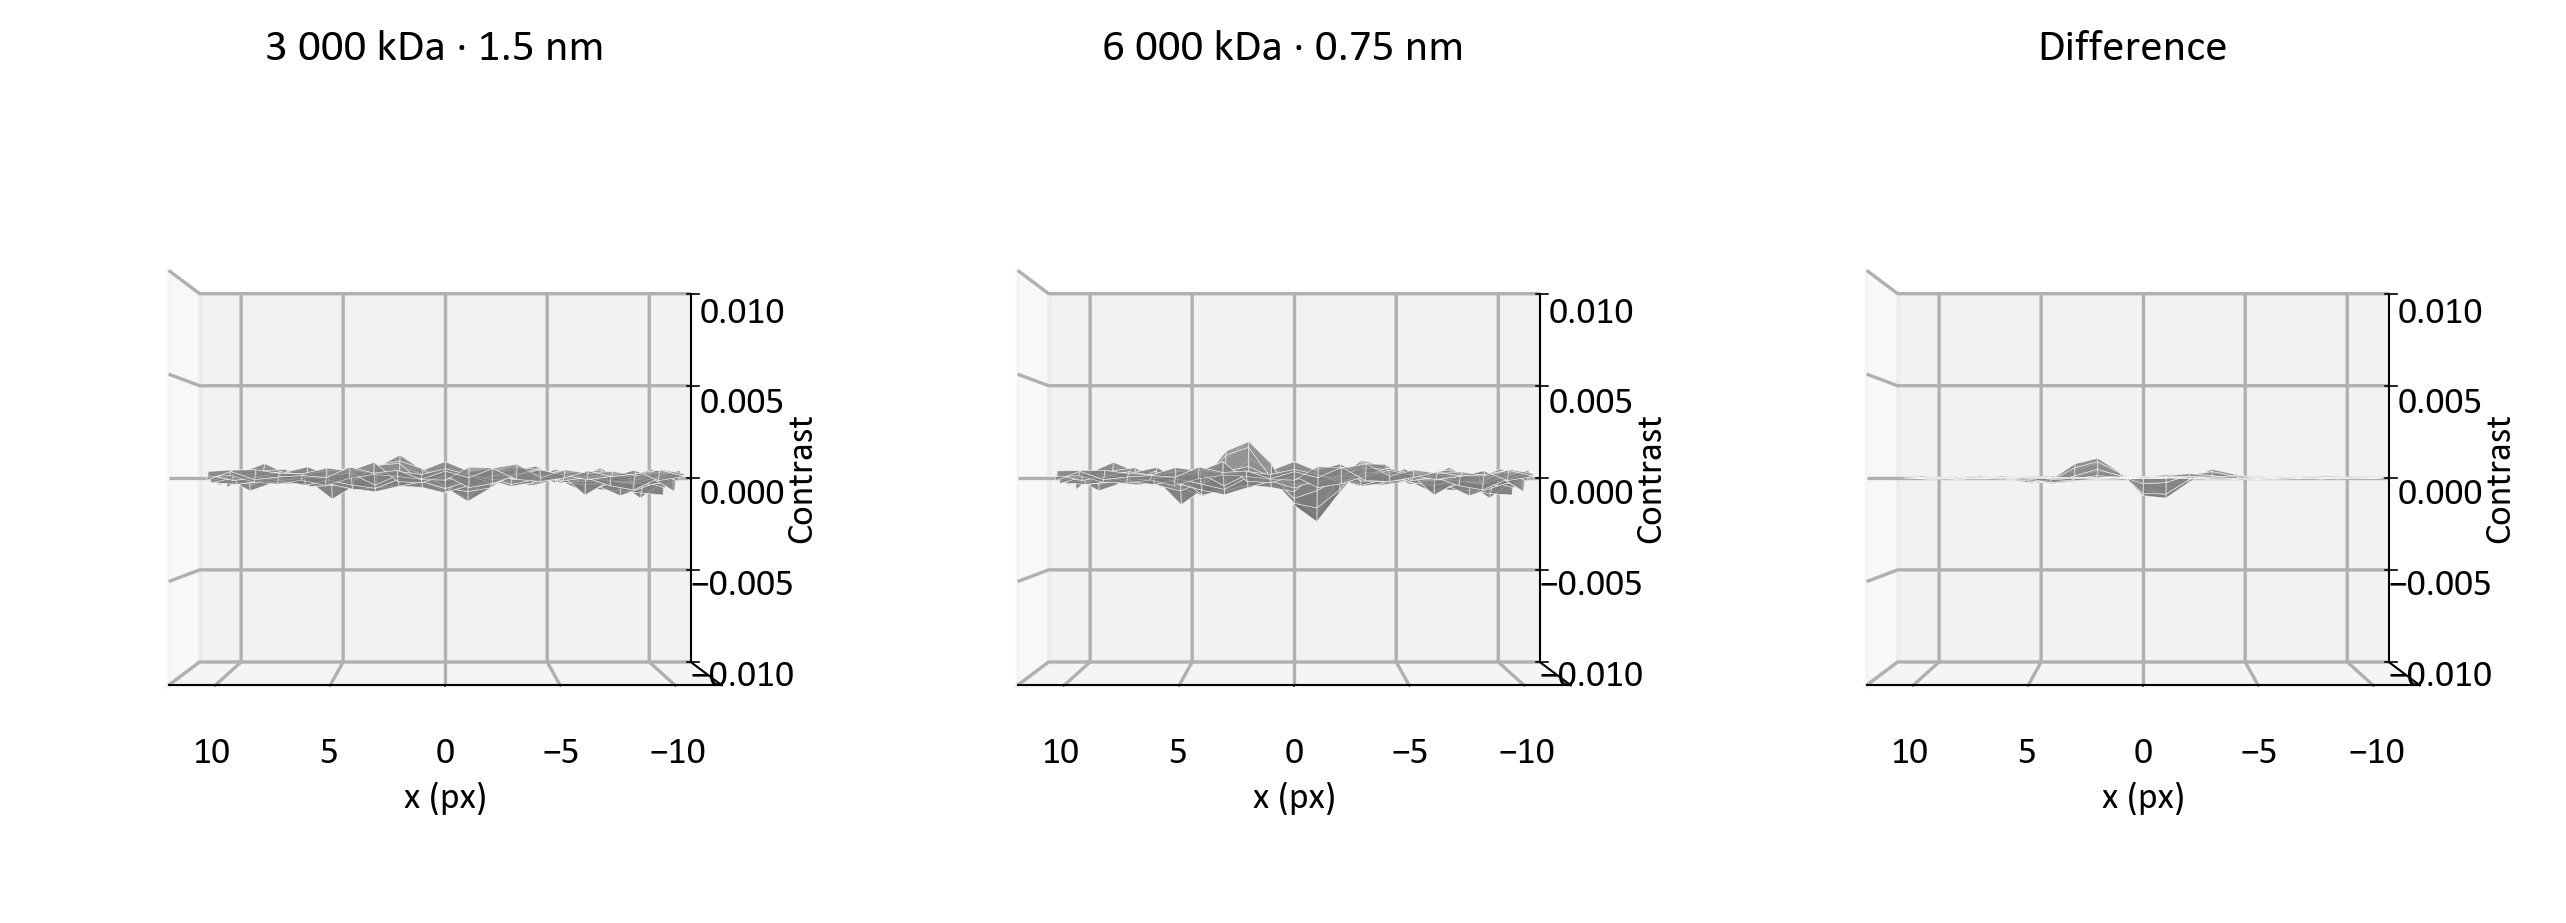

In [32]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers the 3-D projection

fig = plt.figure(
    dpi=300,
    figsize=(1.5 * plotting.DEFAULT_FIG_SIZE[0], plotting.DEFAULT_FIG_SIZE[1]),
)

x = np.linspace(-L_THUM / 2, L_THUM / 2, r_3000.shape[1])
y = np.linspace(-L_THUM / 2, L_THUM / 2, r_3000.shape[0])
X, Y = np.meshgrid(x, y)

vmin, vmax = -0.01, 0.01
surfaces = [
    (r_3000,          f"3 000 kDa · {BUFFER_DISTANCE_NM} nm"),
    (r_6000,          f"6 000 kDa · {BUFFER_DISTANCE_NM / 2} nm"),
    (r_6000 - r_3000, "Difference"),
]

for i, (Z, surf_title) in enumerate(surfaces):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    surf = ax.plot_surface(
        X, Y, Z.astype(float),
        cmap="gray",
        vmin=vmin, vmax=vmax,
        linewidth=0.15,
        alpha=0.7,
        antialiased=True,
    )
    surf.set_edgecolor("white")
    ax.view_init(elev=0, azim=90)
    ax.set_title(surf_title)
    ax.set_xlabel("x (px)")
    ax.yaxis.set_ticks([])
    ax.set_zlabel("Contrast")
    ax.set_zlim(vmin, vmax)

plt.tight_layout()
plt.show()
